# Delitos y sus estadisticas

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('data/delitos.csv')

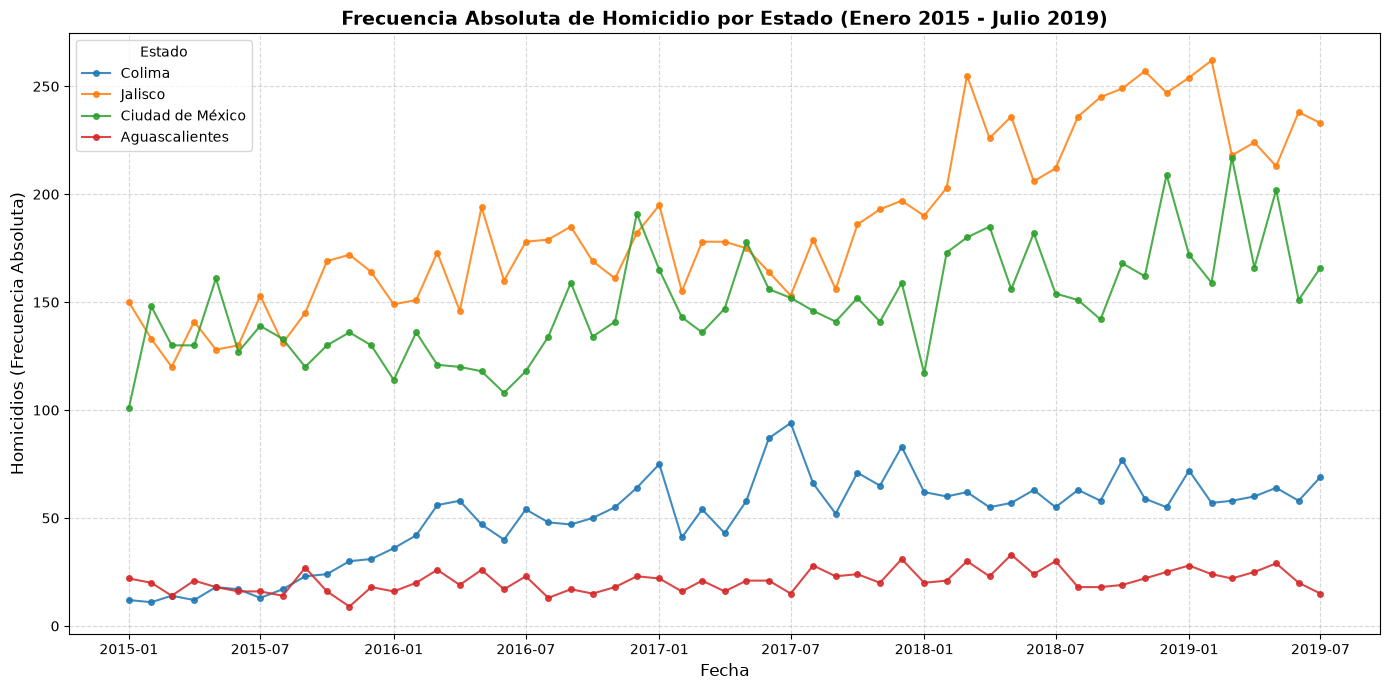

In [4]:
df_homicidios = df[
    (df['tipo_de_delito'] == 'Homicidio') & 
    (df['fecha'] >= '2015-01-01') & 
    (df['fecha'] <= '2019-07-31')
]
delito = df_homicidios['tipo_de_delito'].iloc[0]

# Seleccionamos 3 estados de la república
estados_elegidos = ['Colima', 'Jalisco', 'Ciudad de México', 'Aguascalientes']
df_filtrado = df_homicidios[df_homicidios['entidad'].isin(estados_elegidos)]

# Asegurar que la fecha esté en formato datetime para graficar
df_filtrado['fecha'] = pd.to_datetime(df_filtrado['fecha'])

# Graficar
plt.figure(figsize=(14, 7))
for estado in estados_elegidos:
    data_estado = df_filtrado[df_filtrado['entidad'] == estado].sort_values('fecha')
    plt.plot(data_estado['fecha'], data_estado['frecuencia'], label=estado, marker='o', markersize=4, alpha=0.85)
# He agregado un cambio plt.tittle que agrega el crimen correspondiente, para hacerlo mas dinamico y flexible.
plt.title(f'Frecuencia Absoluta de {delito} por Estado (Enero 2015 - Julio 2019)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Homicidios (Frecuencia Absoluta)', fontsize=12)
plt.legend(title='Estado')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [5]:
print("=== RESPUESTAS A LAS PREGUNTAS DEL EJERCICIO 2 ===\n")

# 1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
# Nota: Todos los homicidios (dolosos y culposos) están bajo 'Homicidio' en la columna 'tipo_de_delito'.
homicidios_colima_2018 = df[(df['entidad'] == 'Colima') & (df['anio'] == 2018) & (df['tipo_de_delito'] == 'Homicidio')]['frecuencia'].sum()
print(f"1. Homicidios en Colima durante 2018 (total unificado): {homicidios_colima_2018:.0f}")

# 2. ¿Cuántos robos de vehículo automotor ha habido en el 2019?
# Nota: Todos los robos están bajo 'Robo' en la columna 'tipo_de_delito'.
robos_2019 = df[(df['anio'] == 2019) & (df['tipo_de_delito'] == 'Robo')]['frecuencia'].sum()
print(f"2. Robos en la República Mexicana durante 2019 (total unificado): {robos_2019:.0f}")

# 3. Obten la suma de homicidos y feminicidios en toda la República Mexicana en cada año.
homicidios_feminicidios = df[df['tipo_de_delito'].isin(['Homicidio', 'Feminicidio'])]
suma_anual = homicidios_feminicidios.groupby('anio')['frecuencia'].sum().reset_index()
print("\n3. Suma anual de Homicidios y Feminicidios en todo el país:")
display(suma_anual)

# 4. ¿En qué mes y en qué entidad (el dataset no tiene municipios) ha ocurrido el mayor número de feminicidios?
df_feminicidios = df[df['tipo_de_delito'] == 'Feminicidio']
max_fem_registro = df_feminicidios.loc[df_feminicidios['frecuencia'].idxmax()]
print(f"\n4. Registro mensual con mayor número de feminicidios:")
print(f"   - Estado (Entidad): {max_fem_registro['entidad']}")
print(f"   - Mes: {max_fem_registro['nombre_mes']} de {max_fem_registro['anio']}")
print(f"   - Cantidad en el mes: {max_fem_registro['frecuencia']:.0f} feminicidios")

# 5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?
fem_anual_estado = df_feminicidios.groupby(['anio', 'entidad'])['frecuencia'].sum().reset_index()
max_fem_anual_estado = fem_anual_estado.loc[fem_anual_estado['frecuencia'].idxmax()]
print(f"\n5. Mayor número de feminicidios acumulados en un año completo por estado:")
print(f"   - Estado (Entidad): {max_fem_anual_estado['entidad']}")
print(f"   - Año: {max_fem_anual_estado['anio']}")
print(f"   - Cantidad acumulada: {max_fem_anual_estado['frecuencia']:.0f} feminicidios")

=== RESPUESTAS A LAS PREGUNTAS DEL EJERCICIO 2 ===

1. Homicidios en Colima durante 2018 (total unificado): 726
2. Robos en la República Mexicana durante 2019 (total unificado): 766096

3. Suma anual de Homicidios y Feminicidios en todo el país:


,anio,frecuencia
0,2015,31744.0
1,2016,36018.0
2,2017,42068.0
3,2018,45385.0
4,2019,45822.0
5,2020,44223.0
6,2021,44960.0
7,2022,43845.0
8,2023,42846.0
9,2024,22307.0



4. Registro mensual con mayor número de feminicidios:
   - Estado (Entidad): México
   - Mes: julio de 2020
   - Cantidad en el mes: 19 feminicidios

5. Mayor número de feminicidios acumulados en un año completo por estado:
   - Estado (Entidad): México
   - Año: 2020
   - Cantidad acumulada: 151 feminicidios


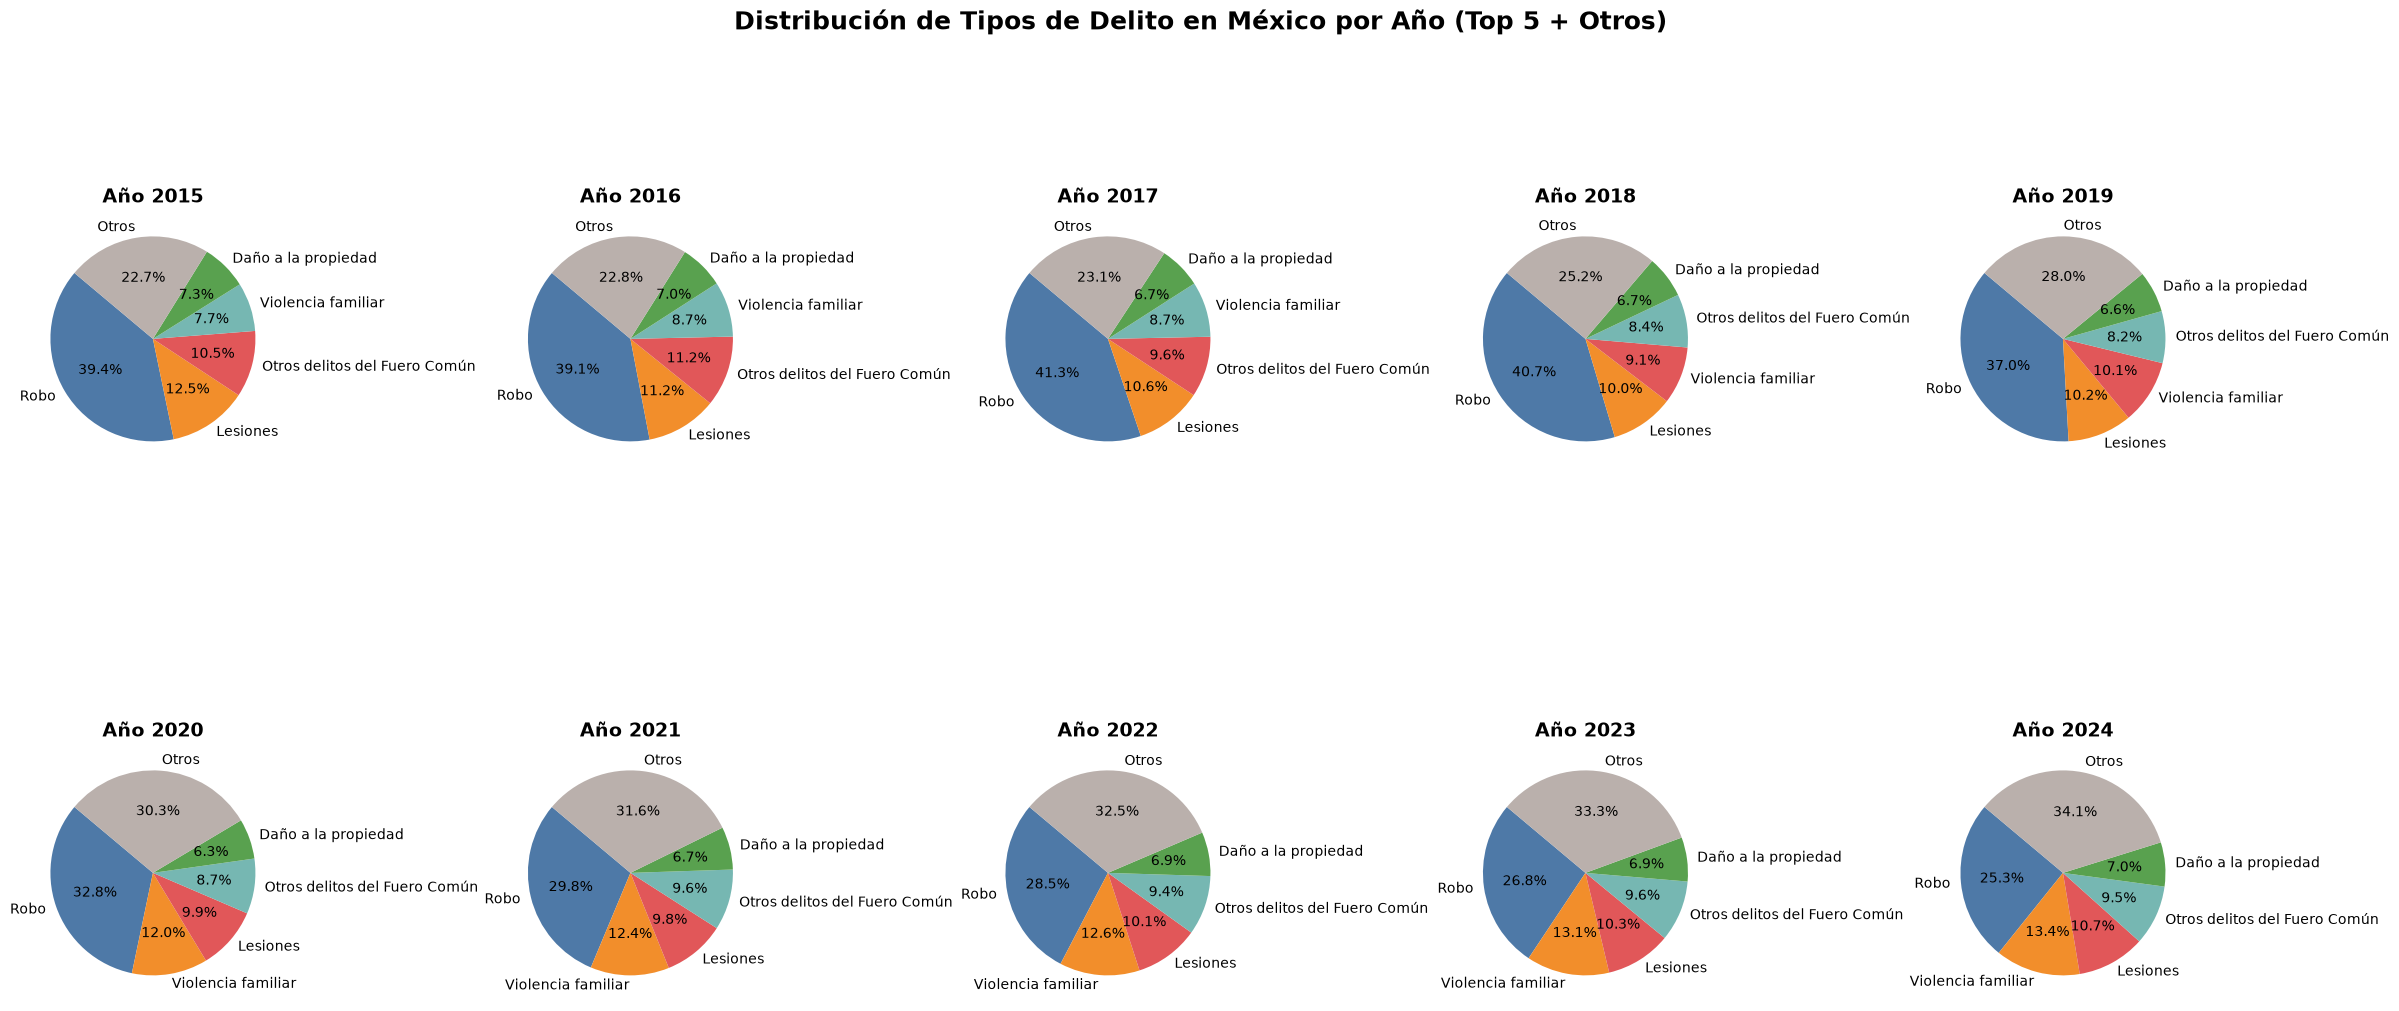

In [6]:
# Ejercicio 3: Gráfica de pastel de tipos de delito para cada año
# Agrupamos los delitos principales (Top 5) y catalogamos el resto como 'Otros' para que sea legible.
years = sorted(df['anio'].unique())

# Configurar cuadrícula de subplots
fig, axes = plt.subplots(2, 5, figsize=(24, 12))
axes = axes.flatten()

colores = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#bab0ac']

for i, yr in enumerate(years):
    df_yr = df[df['anio'] == yr]
    crimes_summary = df_yr.groupby('tipo_de_delito')['frecuencia'].sum().reset_index()
    crimes_summary = crimes_summary.sort_values(by='frecuencia', ascending=False)
    
    # Tomamos Top 5 y agrupamos el resto en 'Otros'
    top5 = crimes_summary.head(5)
    others_val = crimes_summary.iloc[5:]['frecuencia'].sum()
    others_df = pd.DataFrame([{'tipo_de_delito': 'Otros', 'frecuencia': others_val}])
    
    plot_data = pd.concat([top5, others_df], ignore_index=True)
    
    # Graficar pastel en el respectivo subplot
    axes[i].pie(
        plot_data['frecuencia'], 
        labels=plot_data['tipo_de_delito'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colores,
        textprops={'fontsize': 10}
    )
    axes[i].set_title(f'Año {yr}', fontsize=14, fontweight='bold')

plt.suptitle('Distribución de Tipos de Delito en México por Año (Top 5 + Otros)', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
